# EXPERIMENT 2 NOTEBOOK: USEFUL AXIOM

### Installing LTN (provided in .yml , but just in case)

In [ ]:
pip install ltn

### Imports and notebook parameters

In [ ]:
import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.1)

import ltn

# Paràmetres que pots ajustar fàcilment
BATCH_SIZE = 128
LR = 5e-4
EPOCHS = 1500
K_NEIGHBORS = 3        # 3 abans + 3 després -> 6 veïns per punt
LAMBDA_LOGIC = 0.05     # pes de la lògica (0.0..1.0)

CSV_PATH = "data/height_weight_train.csv"


### Data Loading

In [ ]:
# Data loading
df = pd.read_csv(CSV_PATH)
# df = pd.read_csv('height_weight_train.csv')
df = df.sample(frac=1)  # shuffle

# Feature and target
x = df[['height_m']].astype(np.float32)
y = df[['weight']].astype(np.float32)

split = int(0.8 * len(df))
x_train, y_train = x[:split], y[:split]
x_test,  y_test  = x[split:], y[split:]

# Datasets
ds_train = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)
ds_test  = tf.data.Dataset.from_tensor_slices((x_test,  y_test)).batch(BATCH_SIZE)

print("Train:", x_train.shape, y_train.shape)
print("Test:",  x_test.shape,  y_test.shape)

Train: (240, 1) (240, 1)
Test: (60, 1) (60, 1)


## Knowledge Base

#### Model and axioms predicates

In [ ]:
# LTN MLP model with 1D entry
model_f = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(8, activation="elu"),
    tf.keras.layers.Dense(8, activation="elu"),
    tf.keras.layers.Dense(1)   # sortida escalar
])

# LTN Function that wraps the model
f = ltn.Function(model_f)

# Regression predicate with robust equalty (exp)
eq = ltn.Predicate.Lambda(
    lambda args: tf.exp(-0.01 * tf.abs(args[0] - args[1]))
)

# Soft sigmoid predicates for monotonicity axiom.
g = ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (args[0] - args[1])))  # x1 >= x2
h = ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (args[0] - args[1])))  # f(x1) >= f(x2)


### Logical operators

We use the classical Product real Logic configuration. We defined 2 different ForAll operators, a soft one for monotonicity axiom and a strict one for regression axiom.

In [ ]:
# Strict Forall for regression axiom (p=2, pMeanError)
Forall_reg = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=4), semantics="forall")

# Soft Forall for monotonicity axiom(p=1, pMean)
Forall_mon = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=1), semantics="forall")

Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Or = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Exists = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2), semantics="exists")
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())

#### Regression axiom

In [ ]:
def regression_axiom(x_data, y_data):
    x_var = ltn.Variable("x", x_data)
    y_var = ltn.Variable("y", y_data)
    return Forall_reg(ltn.diag(x_var, y_var), eq([f(x_var), y_var])).tensor


#### Monotonicity axiom

Neighbour defining function for computing the monotonicity near a point.

In [ ]:
def neighbor_pairs_from_batch(x_batch, k=3):

    # Ensure its a numpy array
    if isinstance(x_batch, tf.Tensor):
        x_np = x_batch.numpy()
    else:
        x_np = np.asarray(x_batch)

    N = x_np.shape[0]
    if N <= 1:
        return tf.constant([], shape=(0,1), dtype=tf.float32), tf.constant([], shape=(0,1), dtype=tf.float32)

    # Order by the value of x
    order = np.argsort(x_np[:,0])
    pairs_idx = []
    for pos in range(N):
        i = order[pos]
        # previous neighbours
        for offset in range(1, k+1):
            jpos = pos - offset
            if jpos < 0:
                break
            j = order[jpos]
            pairs_idx.append((i, j))
        # posterior neighbours
        for offset in range(1, k+1):
            jpos = pos + offset
            if jpos >= N:
                break
            j = order[jpos]
            pairs_idx.append((i, j))

    if len(pairs_idx) == 0:
        return tf.constant([], shape=(0,1), dtype=tf.float32), tf.constant([], shape=(0,1), dtype=tf.float32)

    idxs = np.array(pairs_idx, dtype=np.int32)
    x1 = x_np[idxs[:,0], :].astype(np.float32)
    x2 = x_np[idxs[:,1], :].astype(np.float32)

    return tf.convert_to_tensor(x1), tf.convert_to_tensor(x2)


Monotonicity axiom itself.

In [ ]:
def monotonicity_axiom_neighbors(x_batch, k=K_NEIGHBORS):
    x1_t, x2_t = neighbor_pairs_from_batch(x_batch, k=k)
    if tf.shape(x1_t)[0] == 0:
        return tf.constant(1.0, dtype=tf.float32) 

    x1_term = ltn.Variable("x1", x1_t)
    x2_term = ltn.Variable("x2", x2_t)

    f1 = f(x1_term)
    f2 = f(x2_term)

    g_formula = g([x1_term, x2_term])
    h_formula = h([f1, f2])
    impl_formula = Implies(g_formula, h_formula)

    sat = Forall_mon((x1_term, x2_term), impl_formula).tensor
    return sat


#### Groundings inspecting function.

In [ ]:
def inspect_ltn(obj, name="obj", max_values=10):
    print(f"\n=== {name} ===")
    print("Python type:", type(obj))
    # Want to check if it's LTN object with .tensor
    t = None
    if hasattr(obj, "tensor"):
        t = obj.tensor
        print("LTN object with .tensor")
    else:
        t = obj

    if isinstance(t, tf.Tensor):
        arr = t.numpy()
        print("Shape:", arr.shape)
        print("Rank:", arr.ndim)
        print("Dtype:", arr.dtype)
        flat = arr.flatten()
        n = flat.size
        if n == 0:
            print("Empty tensor")
        else:
            print("First values:", flat[:max_values], "..." if n > max_values else "")
    else:
        print("Value:", t)


### Training

In [ ]:
# Optimizer and metrics
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

train_sat_metric = tf.keras.metrics.Mean(name='train_sat')
train_mon_sat_metric = tf.keras.metrics.Mean(name='train_mon_sat')
test_sat_metric  = tf.keras.metrics.Mean(name='test_sat')
test_mon_sat_metric = tf.keras.metrics.Mean(name='test_mon_sat')
train_rmse = tf.keras.metrics.RootMeanSquaredError(name='train_rmse')
test_rmse  = tf.keras.metrics.RootMeanSquaredError(name='test_rmse')


# HISTORY FOR EPOCH (NO FOR BATCH)
monotonicity_train_history = []
regression_train_history = []
monotonicity_test_history = []
regression_test_history = []

# ManualTraining loop (eager)
for epoch in range(1, EPOCHS+1):
    # reset metrics
    train_sat_metric.reset_state()
    train_rmse.reset_state()
    train_mon_sat_metric.reset_state()

    # Train
    for x_b, y_b in ds_train:
        with tf.GradientTape() as tape:
            sat_reg = regression_axiom(x_b, y_b)
            sat_mon = monotonicity_axiom_neighbors(x_b, k=K_NEIGHBORS)

            loss_reg = 1.0 - sat_reg
            loss_mon = 1.0 - sat_mon
            loss = (1.0 - LAMBDA_LOGIC) * loss_reg + LAMBDA_LOGIC * loss_mon

        grads = tape.gradient(loss, f.trainable_variables)
        optimizer.apply_gradients(zip(grads, f.trainable_variables))

        # update metrics 
        train_sat_metric.update_state(sat_reg)
        preds = f.model(x_b)
        train_rmse.update_state(y_b, preds)
        train_mon_sat_metric.update_state(sat_mon)

    monotonicity_train_history.append(float(sat_mon.numpy()))
    regression_train_history.append(float(sat_reg.numpy()))


    # Test
    test_sat_metric.reset_state()
    test_rmse.reset_state()
    test_mon_sat_metric.reset_state()
    for x_b, y_b in ds_test:
        sat_reg = regression_axiom(x_b, y_b)
        sat_mon = monotonicity_axiom_neighbors(x_b, k=K_NEIGHBORS)
        test_sat_metric.update_state(sat_reg)
        preds = f.model(x_b)
        test_rmse.update_state(y_b, preds)
        test_mon_sat_metric.update_state(sat_mon)

    monotonicity_test_history.append(float(sat_mon.numpy()))
    regression_test_history.append(float(sat_reg.numpy()))

    # Print 
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:04d} | train_sat={train_sat_metric.result().numpy():.4f} | test_sat={test_sat_metric.result().numpy():.4f} | train_rmse={train_rmse.result().numpy():.4f} | test_rmse={test_rmse.result().numpy():.4f}")
        print(f"Epoch {epoch:04d} | train_mon_sat={train_mon_sat_metric.result().numpy():.4f} | test_mon_sat={test_mon_sat_metric.result().numpy():.4f}")


Epoch 0001 | train_sat=0.2280 | test_sat=0.2329 | train_rmse=148.9280 | test_rmse=147.0566
Epoch 0001 | train_mon_sat=0.7140 | test_mon_sat=0.7142
Epoch 0050 | train_sat=0.2299 | test_sat=0.2348 | train_rmse=148.0896 | test_rmse=146.2290
Epoch 0050 | train_mon_sat=0.8488 | test_mon_sat=0.8582
Epoch 0100 | train_sat=0.2316 | test_sat=0.2365 | train_rmse=147.3503 | test_rmse=145.4970
Epoch 0100 | train_mon_sat=0.8923 | test_mon_sat=0.8985
Epoch 0150 | train_sat=0.2335 | test_sat=0.2385 | train_rmse=146.4955 | test_rmse=144.6479
Epoch 0150 | train_mon_sat=0.9101 | test_mon_sat=0.9139
Epoch 0200 | train_sat=0.2361 | test_sat=0.2411 | train_rmse=145.3880 | test_rmse=143.5461
Epoch 0200 | train_mon_sat=0.9210 | test_mon_sat=0.9232
Epoch 0250 | train_sat=0.2396 | test_sat=0.2446 | train_rmse=143.8771 | test_rmse=142.0434
Epoch 0250 | train_mon_sat=0.9298 | test_mon_sat=0.9305
Epoch 0300 | train_sat=0.2442 | test_sat=0.2494 | train_rmse=141.9217 | test_rmse=140.0990
Epoch 0300 | train_mon_sat=

In [ ]:
# Inspect a small batch
for x_b, y_b in ds_train.take(1):
    print("Batch shapes:", x_b.shape, y_b.shape)
    # inspect terms
    x1, x2 = neighbor_pairs_from_batch(x_b, k=2)
    inspect_ltn(x_b, "x_batch")
    inspect_ltn(x1, "x1 (pairs)")
    inspect_ltn(x2, "x2 (pairs)")
    # inspect f among a few
    x_var = ltn.Variable("x", x_b[:8])
    fx = f(x_var)
    inspect_ltn(fx, "f(x) for first 8")
    break


Batch shapes: (128, 1) (128, 1)

=== x_batch ===
Python type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape: (128, 1)
Rank: 2
Dtype: float32
First values: [1.4109331 1.8633468 1.8547077 1.4086361 1.4935967 1.438135  1.8369298
 1.4033133 1.6462297 1.7256176] ...

=== x1 (pairs) ===
Python type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape: (506, 1)
Rank: 2
Dtype: float32
First values: [1.4033133 1.4033133 1.4086361 1.4086361 1.4086361 1.4109331 1.4109331
 1.4109331 1.4109331 1.4145895] ...

=== x2 (pairs) ===
Python type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape: (506, 1)
Rank: 2
Dtype: float32
First values: [1.4086361 1.4109331 1.4033133 1.4109331 1.4145895 1.4086361 1.4033133
 1.4145895 1.4188575 1.4109331] ...

=== f(x) for first 8 ===
Python type: <class 'ltn.core.Term'>
LTN object with .tensor
Shape: (8, 1)
Rank: 2
Dtype: float32
First values: [134.0667  157.79135 157.35066 133.94235 138.51222 135.53583 156.44246
 133.65404] 


## Predictions and results

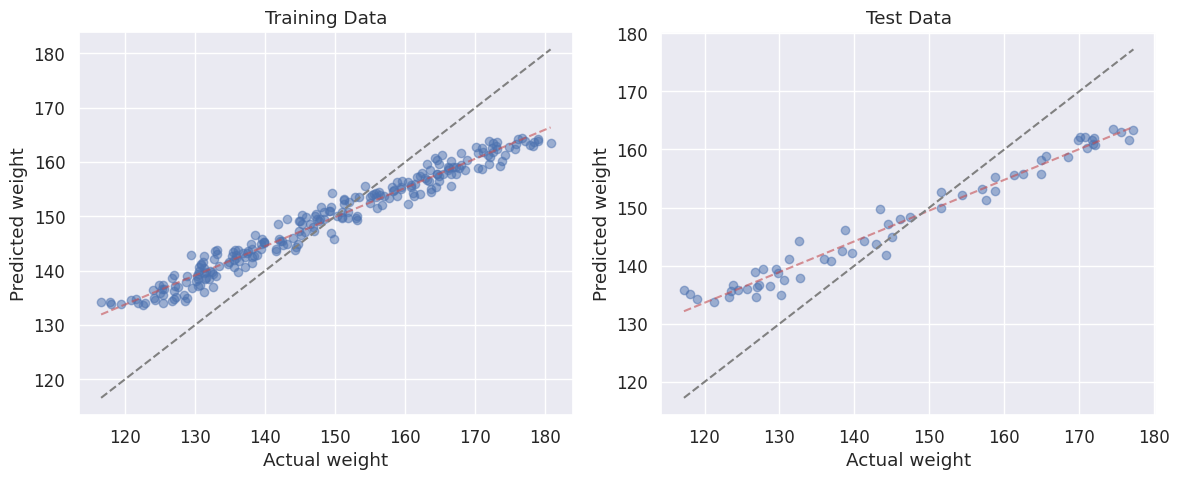

In [ ]:
# Collect predictions
def collect_preds(dataset):
    y_pred = []
    y_true = []
    for x_b, y_b in dataset:
        preds = f.model(x_b).numpy().reshape(-1)
        trues = y_b.numpy().reshape(-1)
        y_pred.extend(preds)
        y_true.extend(trues)
    return np.array(y_true), np.array(y_pred)

y_t_train, y_p_train = collect_preds(ds_train)
y_t_test,  y_p_test  = collect_preds(ds_test)

fig, axs = plt.subplots(1,2,figsize=(12,5))
ax = axs[0]
ax.scatter(y_t_train, y_p_train, alpha=0.5)
m, b = np.polyfit(y_t_train, y_p_train, 1)
ax.plot(np.unique(y_t_train), m*np.unique(y_t_train)+b, color='r', linestyle='--', alpha=0.6)
ax.plot([min(y_t_train), max(y_t_train)], [min(y_t_train), max(y_t_train)], color='gray', linestyle='--')
ax.set_title("Training Data")
ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")

ax = axs[1]
ax.scatter(y_t_test, y_p_test, alpha=0.5)
m, b = np.polyfit(y_t_test, y_p_test, 1)
ax.plot(np.unique(y_t_test), m*np.unique(y_t_test)+b, color='r', linestyle='--', alpha=0.6)
ax.plot([min(y_t_test), max(y_t_test)], [min(y_t_test), max(y_t_test)], color='gray', linestyle='--')
ax.set_title("Test Data")
ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")

plt.tight_layout()
plt.show()


In [ ]:
def plot_height_vs_weight(x, y_true, y_pred, title):
    plt.figure(figsize=(10,5))
    plt.scatter(x, y_true, label="Real Data", alpha=0.5)
    plt.scatter(x, y_pred, label="Model Predictions", alpha=0.5)

    plt.xlabel("Height (m)")
    plt.ylabel("Weight (lb)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


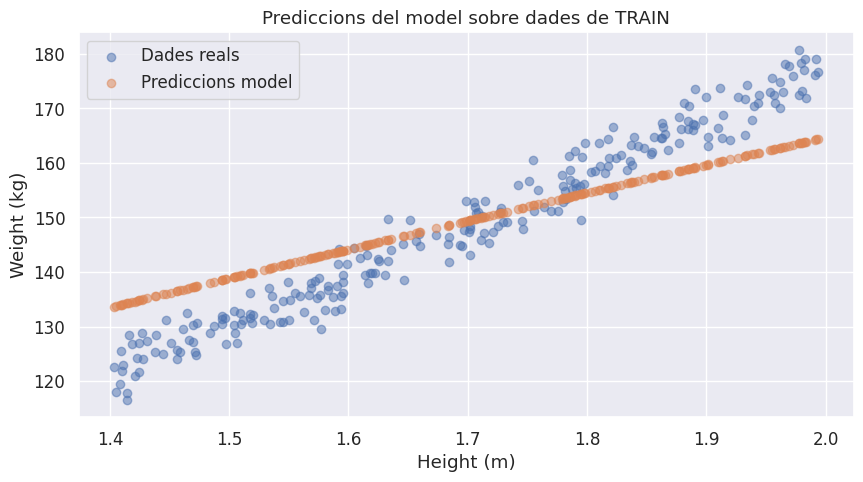

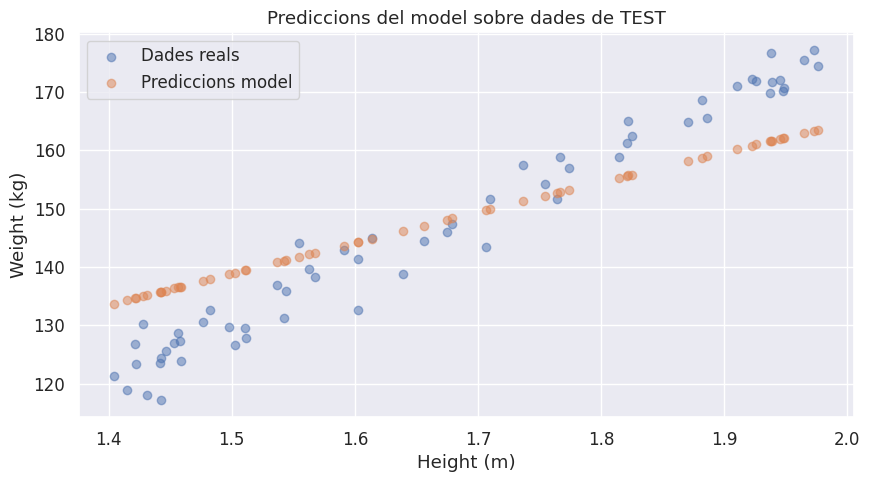

In [ ]:
# TRAIN
x_train_np = x_train.values if hasattr(x_train, "values") else x_train
y_pred_train = f.model(x_train_np).numpy().flatten()
plot_height_vs_weight(
    x_train_np.flatten(),
    y_t_train,
    y_pred_train,
    "Model Predictions over TRAIN Data"
)

# TEST
x_test_np = x_test.values if hasattr(x_test, "values") else x_test
y_pred_test = f.model(x_test_np).numpy().flatten()
plot_height_vs_weight(
    x_test_np.flatten(),
    y_t_test,
    y_pred_test,
    "Model Predictions over TEST Data"
)


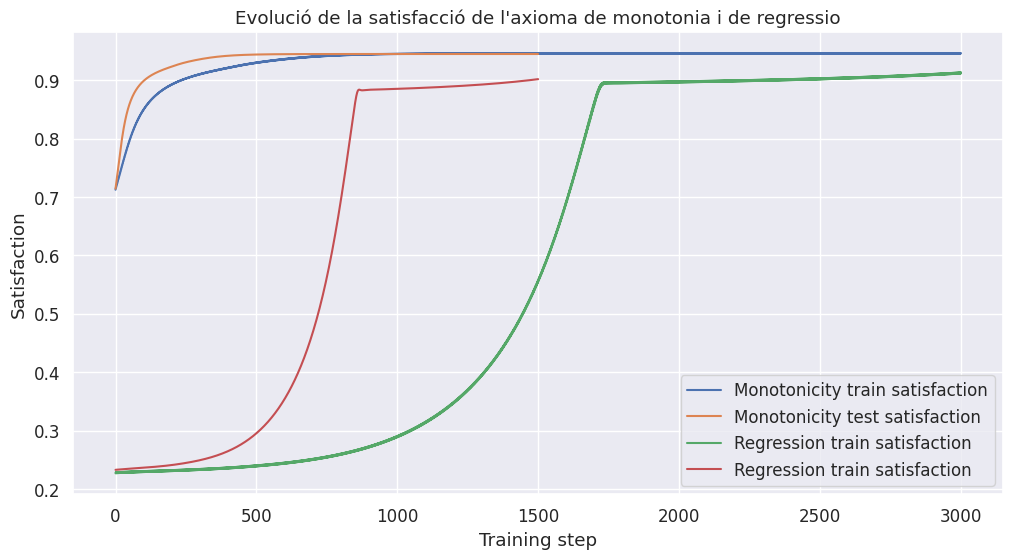

In [ ]:

plt.figure(figsize=(12,6))
plt.plot(monotonicity_train_history, label="Monotonicity train satisfaction")
plt.plot(monotonicity_test_history, label="Monotonicity test satisfaction")
plt.plot(regression_train_history, label="Regression train satisfaction")
plt.plot(regression_test_history, label="Regression test satisfaction")
plt.xlabel("Training step")
plt.ylabel("Satisfaction")
plt.title("Monotony and regression axiom satisfaction evolution")
plt.grid(True)
plt.legend()
plt.show()


## Queries

#### Predicates required for both queries

In [ ]:
# Predicate height < c
def less_than_height(c):
    return ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (c - args[0])))

# Predicate height > c
def greater_than_height(c):
    return ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (args[0] - c)))

# Predicate weight < c
def less_than_weight(c):
    return ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (c - args[0])))

# Predicate weight > c
def greater_than_weight(c):
    return ltn.Predicate.Lambda(lambda args: tf.sigmoid(20.0 * (args[0] - c)))


#### Query A: Any person shorter than 1.75 m, weights less than 70 lbs.

In [ ]:
# Query A: height < 1.75  =>  weight < 70
H_lt_175 = less_than_height(1.75)
W_lt_70  = less_than_weight(70.0)

def query_A(x_batch, y_batch):
    x_var = ltn.Variable("x", x_batch)
    y_var = ltn.Variable("y", y_batch)

    premise = H_lt_175([x_var])
    conclusion = W_lt_70([y_var])
    implication = Implies(premise, conclusion)

    return Forall_mon((x_var, y_var), implication).tensor


#### Query B: Any person taller than 1.65 m, weights more than 75 lbs.

In [ ]:
# Query B: height > 1.65  =>  weight > 75
H_gt_165 = greater_than_height(1.65)
W_gt_75  = greater_than_weight(75.0)

def query_B(x_batch, y_batch):
    x_var = ltn.Variable("x", x_batch)
    y_var = ltn.Variable("y", y_batch)

    premise = H_gt_165([x_var])
    conclusion = W_gt_75([y_var])
    implication = Implies(premise, conclusion)

    return Forall_mon((x_var, y_var), implication).tensor


In [ ]:
for x_b, y_b in ds_test.take(1):
    qA = query_A(x_b, y_b).numpy()
    qB = query_B(x_b, y_b).numpy()

print("Query A (height < 1.75 => weight < 70):", qA)
print("Query B (height > 1.65 => weight > 75):", qB)


Consulta A (height < 1.75 => weight < 70): 0.36795947
Consulta B (height > 1.65 => weight > 75): 0.99995106


### Out Of Distribution (OOD) data

In [ ]:
# Load OOD data
df_ood = pd.read_csv("data/height_weight_extrapolation.csv")

x_ood = df_ood[["height_m"]].astype(np.float32).values
y_ood = df_ood[["weight"]].astype(np.float32).values

ds_ood = tf.data.Dataset.from_tensor_slices((x_ood, y_ood)).batch(128)

print("OOD Sample loaded:", x_ood.shape, y_ood.shape)
df_ood.head()


Mostra OOD carregada: (400, 1) (400, 1)


,height_m,weight
0,1.00000,91.115400
1,1.00201,91.018210
2,1.00402,92.947840
3,1.00603,91.257070
4,1.00804,88.914444


DataSet evaluation function. It returns the RMSE, the satisfaction degree of the regression axiom and of the monotonicity axiom.

In [ ]:
def evaluate_dataset(dataset):
   
    rmse_metric = tf.keras.metrics.RootMeanSquaredError()
    sat_reg_metric = tf.keras.metrics.Mean()
    sat_mon_metric = tf.keras.metrics.Mean()

    for x_b, y_b in dataset:
        preds = f.model(x_b)
        rmse_metric.update_state(y_b, preds)

        sat_reg = regression_axiom(x_b, y_b)
        sat_mon = monotonicity_axiom_neighbors(x_b, k=K_NEIGHBORS)

        sat_reg_metric.update_state(sat_reg)
        sat_mon_metric.update_state(sat_mon)

    return {
        "rmse": float(rmse_metric.result().numpy()),
        "sat_reg": float(sat_reg_metric.result().numpy()),
        "sat_mon": float(sat_mon_metric.result().numpy())
    }


### OOD data results

In [ ]:
results_ood = evaluate_dataset(ds_ood)

print("=== OOD Results ===")
print(f"RMSE: {results_ood['rmse']:.4f}")
print(f"Satisfacció regressió: {results_ood['sat_reg']:.4f}")
print(f"Satisfacció monotonia: {results_ood['sat_mon']:.4f}")


=== Resultats OOD ===
RMSE: 20.0528
Satisfacció regressió: 0.8019
Satisfacció monotonia: 0.8632


#### Predicted vs Real value comparison

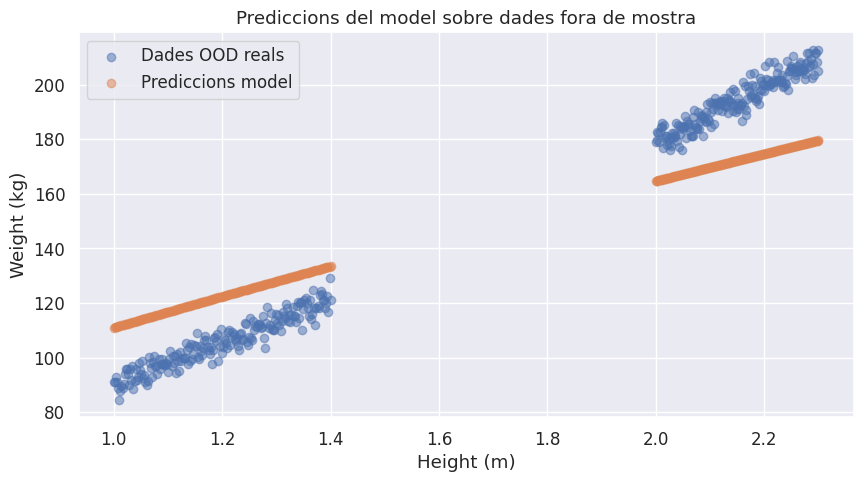

In [ ]:
# Predictions OOD
y_pred_ood = f.model(x_ood).numpy().flatten()

plt.figure(figsize=(10,5))
plt.scatter(x_ood, y_ood, label="Real OOD data", alpha=0.5)
plt.scatter(x_ood, y_pred_ood, label="Model predictions", alpha=0.5)
plt.xlabel("Height (m)")
plt.ylabel("Weight (lb)")
plt.title("Model predictions over OOD data")
plt.legend()
plt.grid(True)
plt.show()


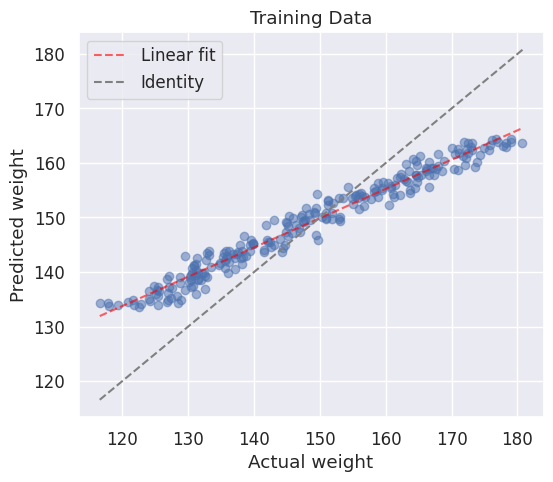

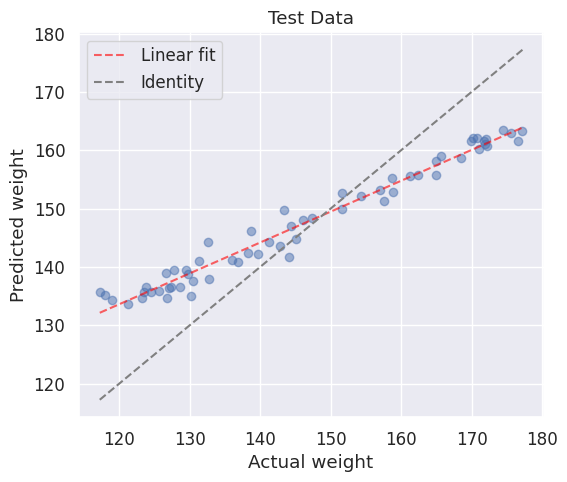

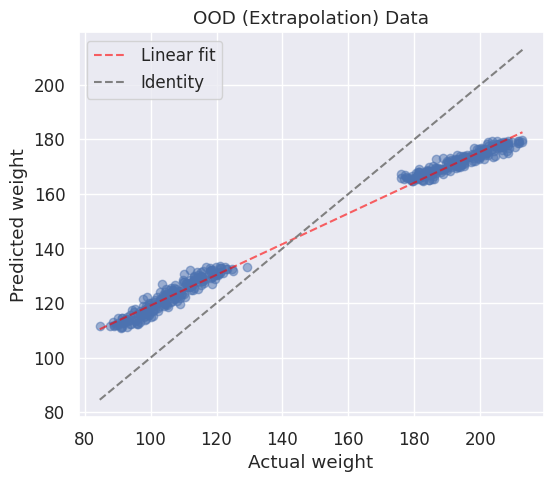

In [ ]:
def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Lineal fit
    m, b = np.polyfit(y_true, y_pred, 1)
    xs = np.linspace(min(y_true), max(y_true), 100)
    plt.plot(xs, m*xs + b, color='red', linestyle='--', alpha=0.6, label="Linear fit")

    # Identity line
    plt.plot(xs, xs, color='gray', linestyle='--', label="Identity")

    plt.xlabel("Actual weight")
    plt.ylabel("Predicted weight")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# TRAIN
y_t_train, y_p_train = collect_preds(ds_train)
plot_pred_vs_actual(y_t_train, y_p_train, "Training Data")

# TEST
y_t_test, y_p_test = collect_preds(ds_test)
plot_pred_vs_actual(y_t_test, y_p_test, "Test Data")

# OOD (Extrapolation)
y_t_ood, y_p_ood = collect_preds(ds_ood)
plot_pred_vs_actual(y_t_ood, y_p_ood, "OOD (Extrapolation) Data")

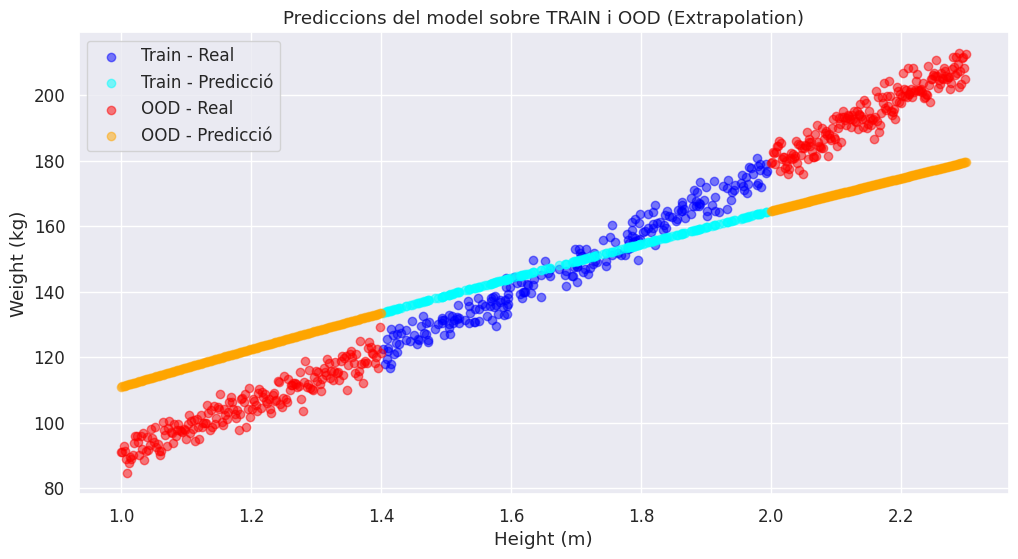

In [ ]:
# Prepare TRAIN data
x_train_np = x_train.values if hasattr(x_train, "values") else x_train
y_pred_train = f.model(x_train_np).numpy().flatten()

# Prepare OOD data 
x_ood_np = x_ood
y_pred_ood = f.model(x_ood_np).numpy().flatten()

plt.figure(figsize=(12,6))

# TRAIN: reals and predictions
plt.scatter(x_train_np, y_t_train, label="Train - Real", alpha=0.5, color="blue")
plt.scatter(x_train_np, y_pred_train, label="Train - Prediction", alpha=0.5, color="cyan")

# OOD: reals and predictions
plt.scatter(x_ood_np, y_t_ood, label="OOD - Real", alpha=0.5, color="red")
plt.scatter(x_ood_np, y_pred_ood, label="OOD - Prediction", alpha=0.5, color="orange")

plt.xlabel("Height (m)")
plt.ylabel("Weight (lb)")
plt.title("Model predictions over TRAIN and OOD (Extrapolation)")
plt.grid(True)
plt.legend()
plt.show()
